# 01 — Market Overview

High-level view of the German IT job market from this dataset. Covers the shape of the data, dominant job families, posting activity over time, top hiring companies, and how the postings are split across sources.

In [14]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [15]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, time_series, stacked_bar
from analysis.filters import explode_json_col

df.head(3)

,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## Job Family Distribution

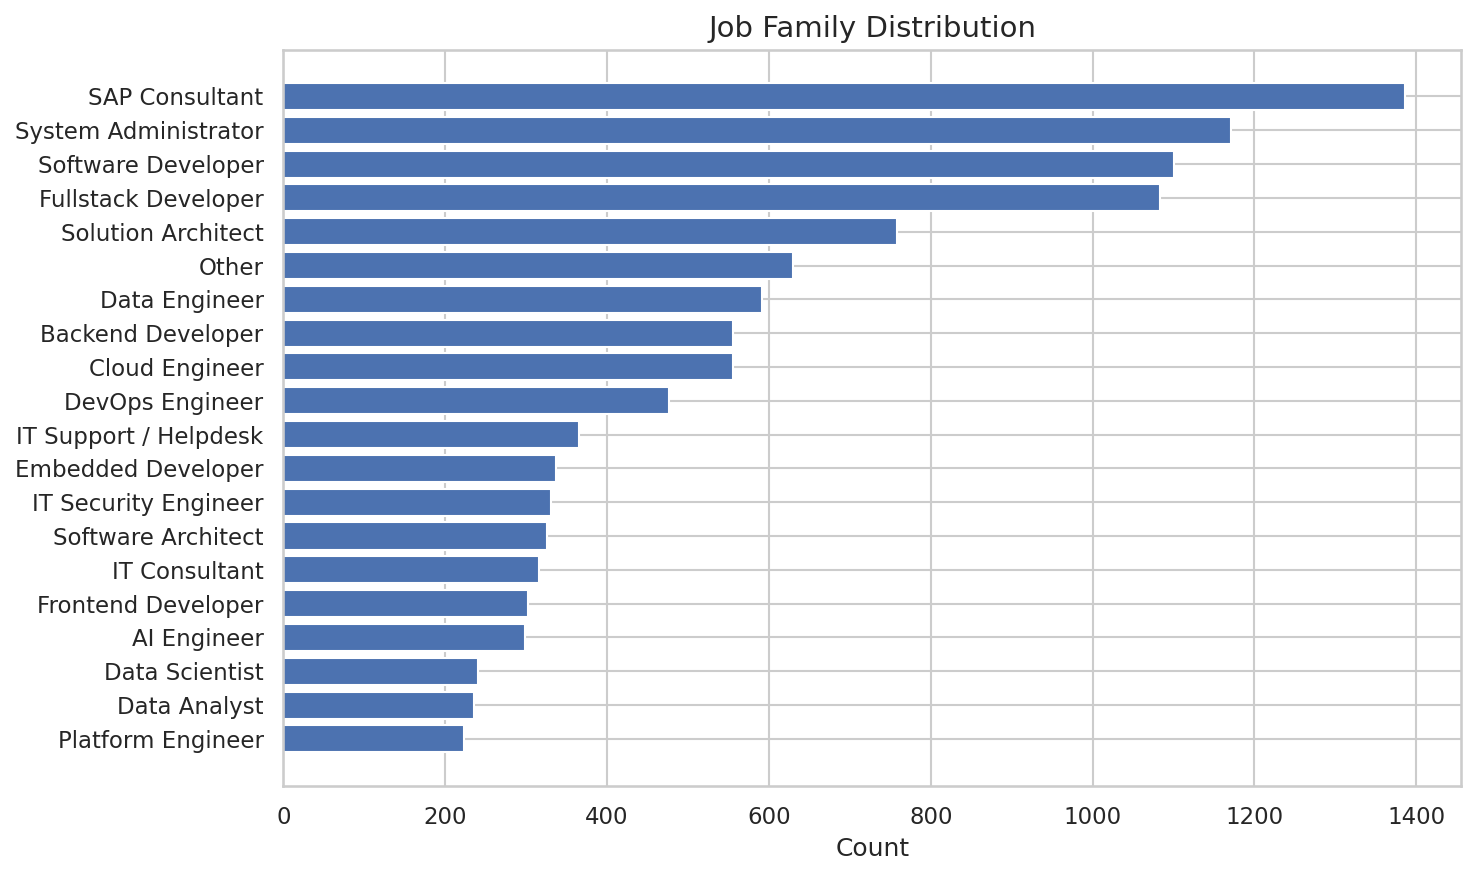

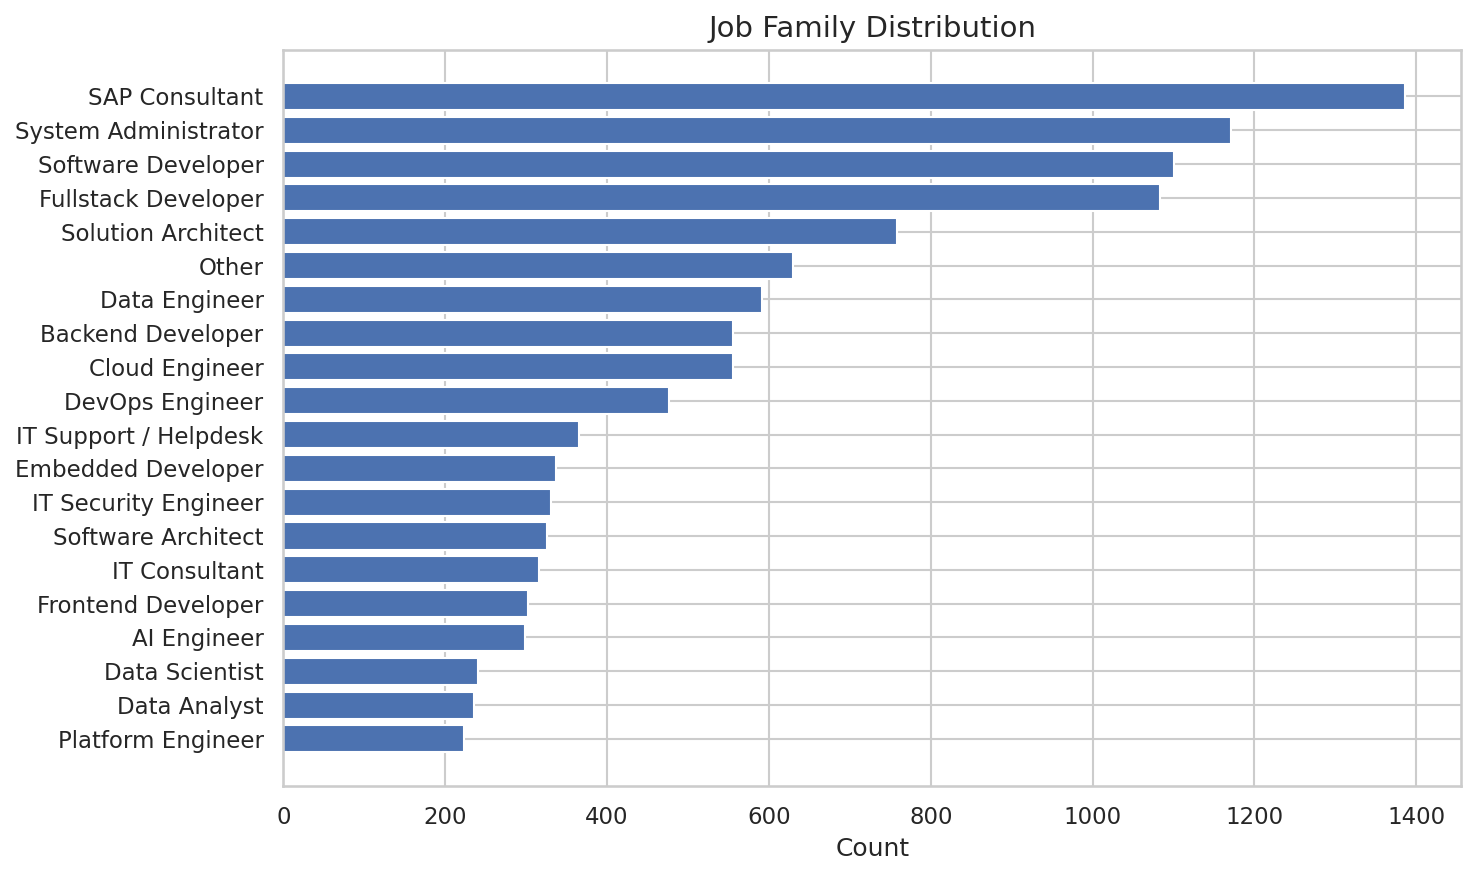

In [16]:
horizontal_bar(
    df["job_family"],
    "Job Family Distribution",
    top_n=20,
    save_as="01_job_family.png",
)

## Postings Over Time

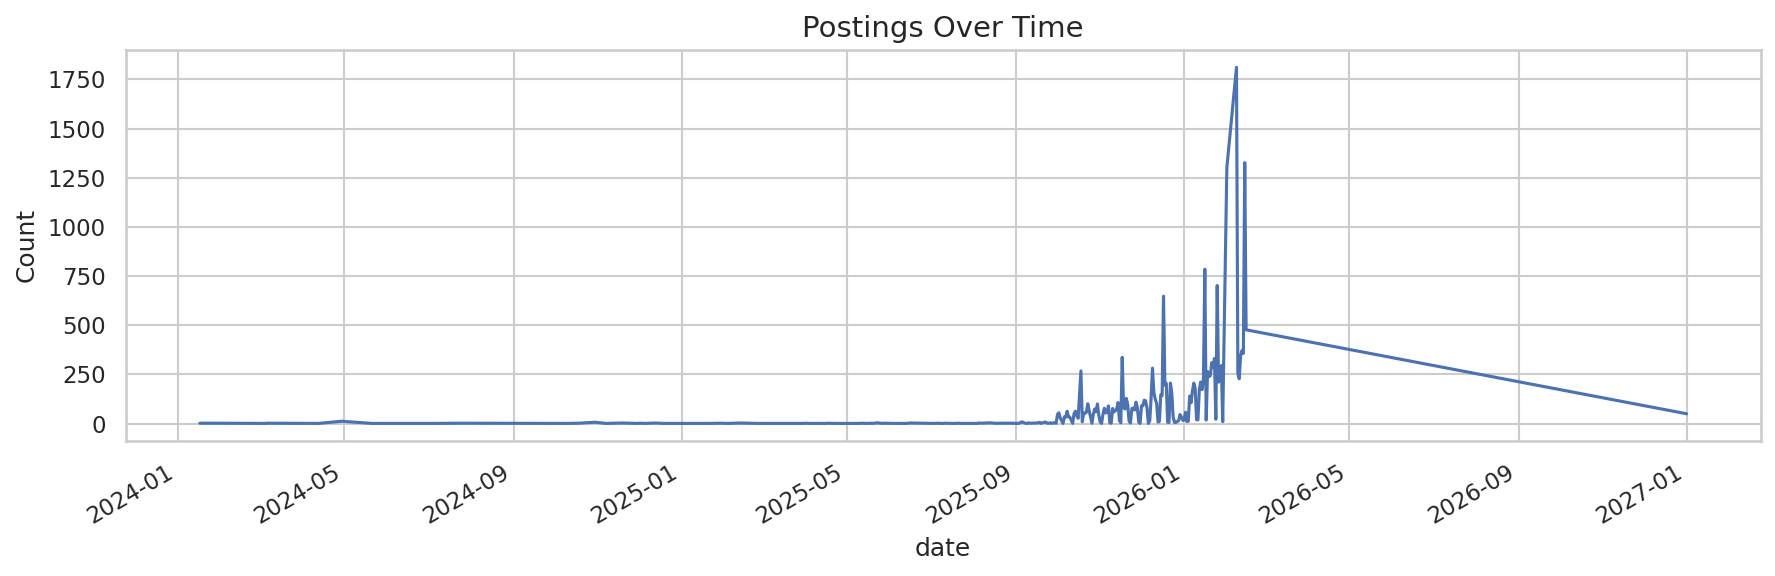

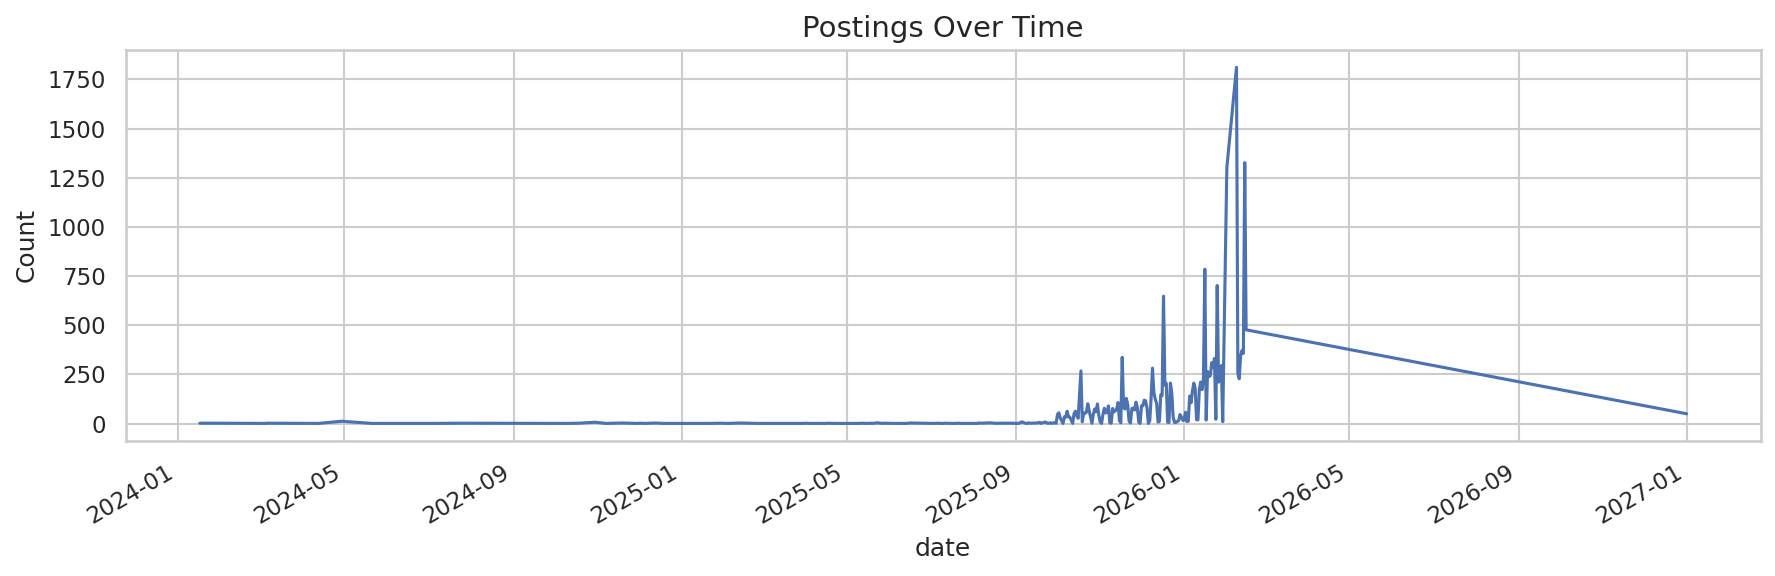

In [17]:
import pandas as pd

postings_by_date = (
    df[df["date_posted"].notna()]["date_posted"]
    .value_counts()
    .rename_axis("date")
    .sort_index()
)
postings_by_date.index = pd.to_datetime(postings_by_date.index)
time_series(postings_by_date, "Postings Over Time", save_as="01_postings_time.png")

## Top Companies

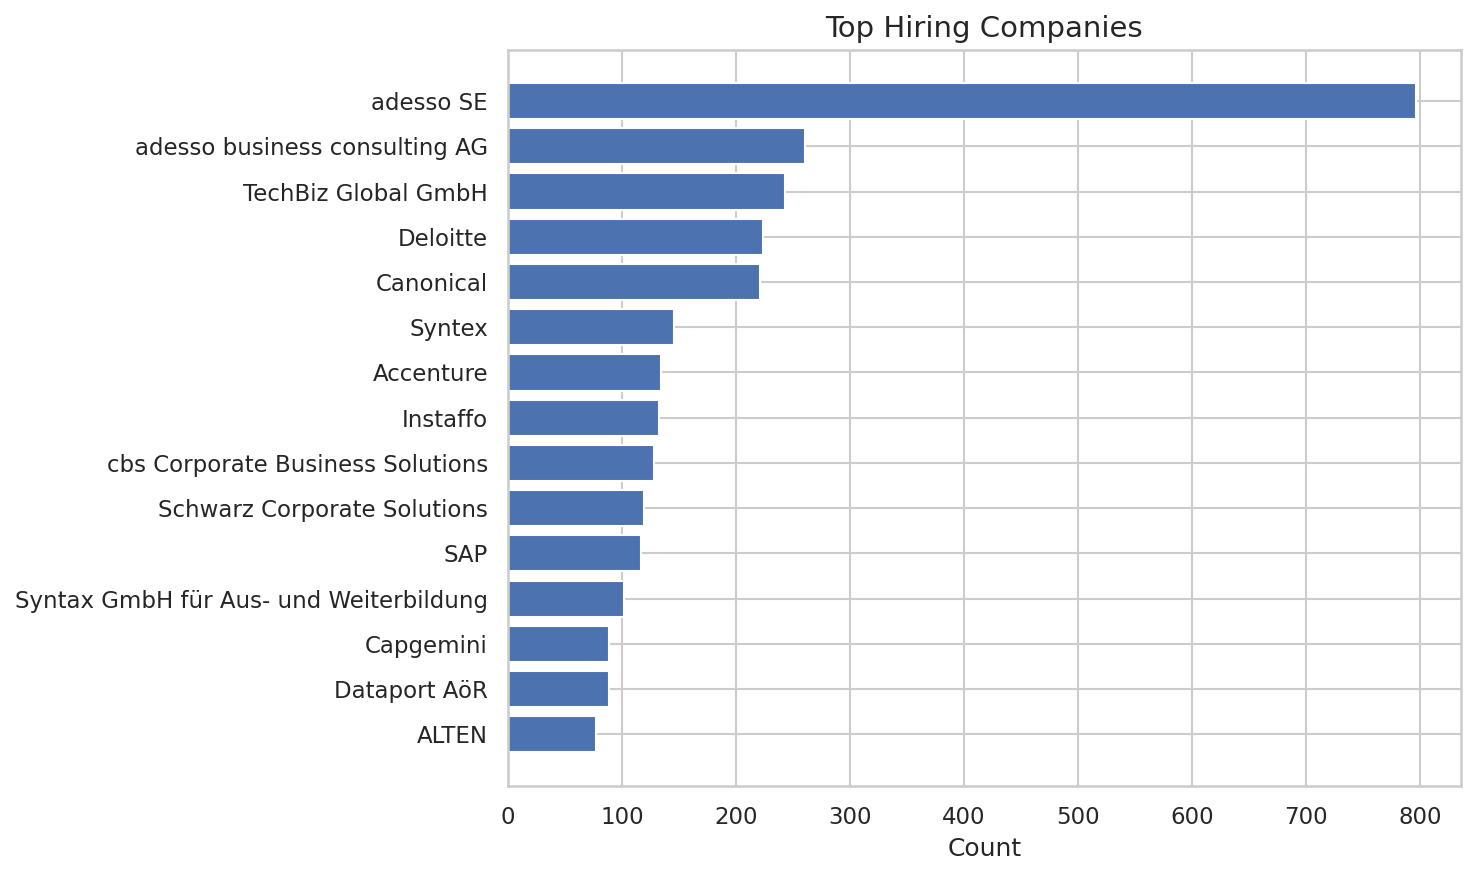

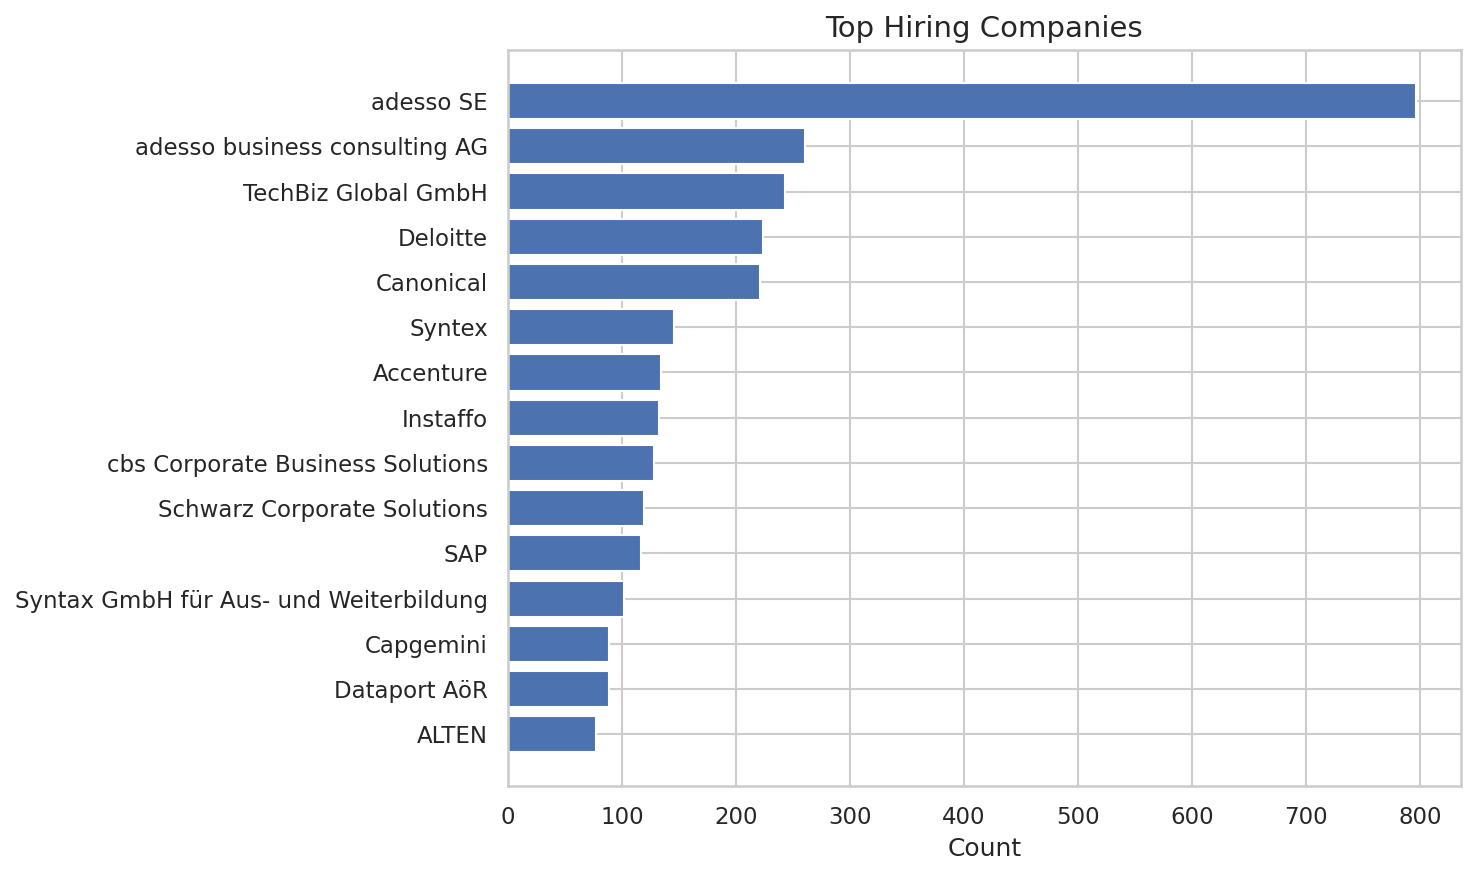

In [18]:
horizontal_bar(
    df[df["company_name"].notna()]["company_name"],
    "Top Hiring Companies",
    top_n=15,
    save_as="01_companies.png",
)

## Source Split (Indeed vs LinkedIn)

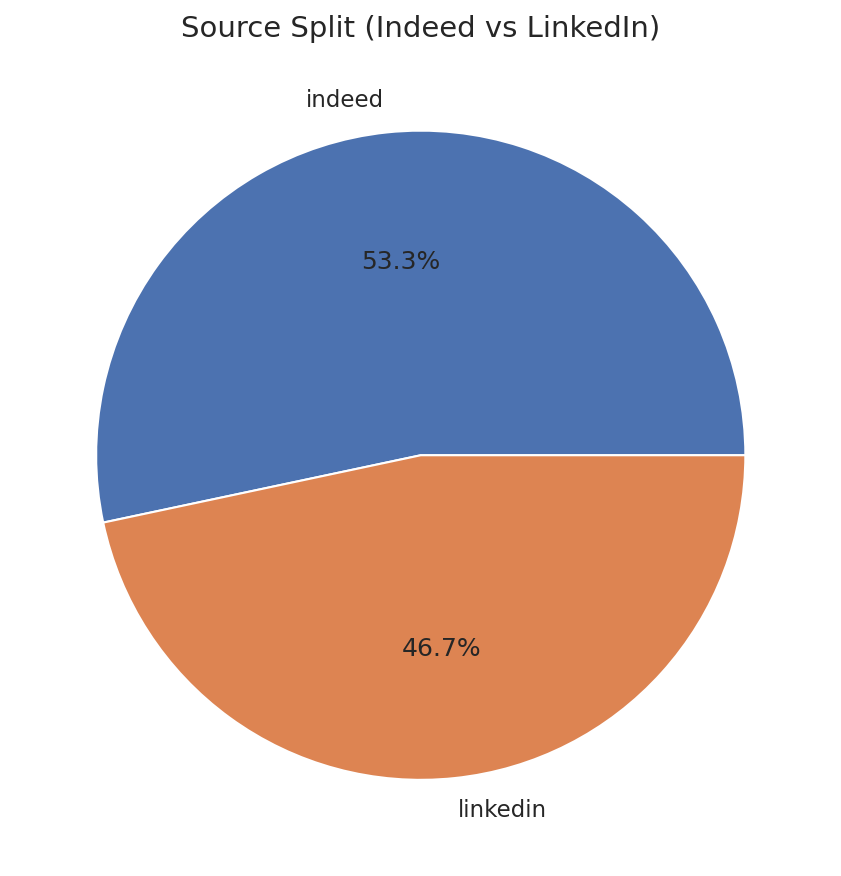

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
df["site"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax)
ax.set_title("Source Split (Indeed vs LinkedIn)")
ax.set_ylabel("")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "01_source_split.png", dpi=150)